In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

### LOAD DATA

In [6]:
df = pd.read_csv("insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<Axes: xlabel='age', ylabel='Count'>

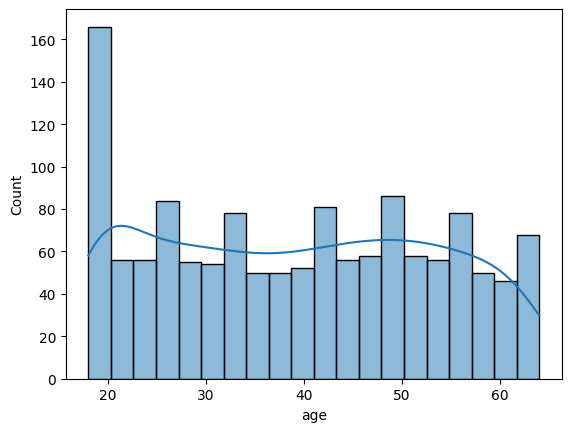

In [11]:
sns.histplot(data=df,x="age",kde=True,bins=20)

<Axes: xlabel='bmi', ylabel='Count'>

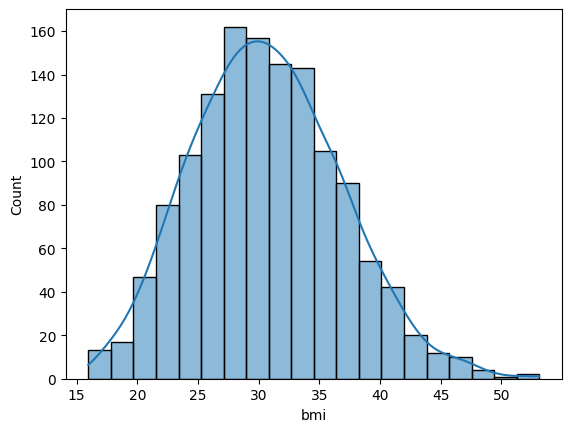

In [12]:
sns.histplot(data=df,x="bmi",kde=True,bins=20)

<Axes: xlabel='children', ylabel='Count'>

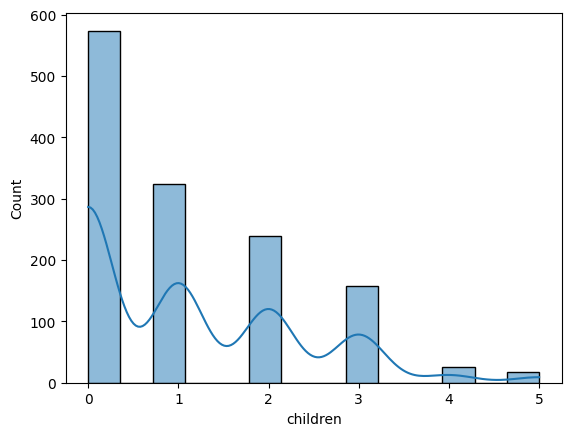

In [14]:
sns.histplot(data=df,x="children",kde=True)

<Axes: xlabel='children', ylabel='charges'>

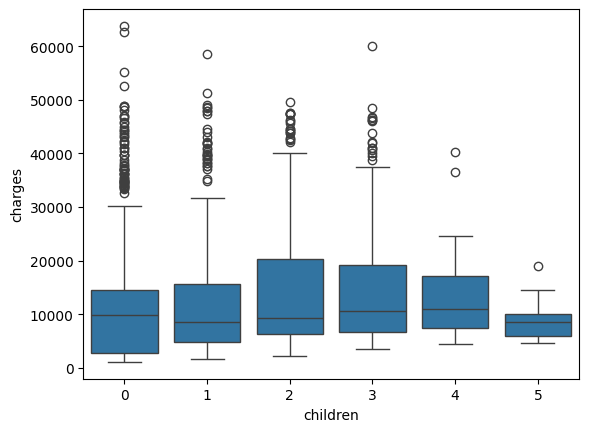

In [18]:
sns.boxplot(data=df,x="children",y="charges")

<Axes: xlabel='smoker', ylabel='charges'>

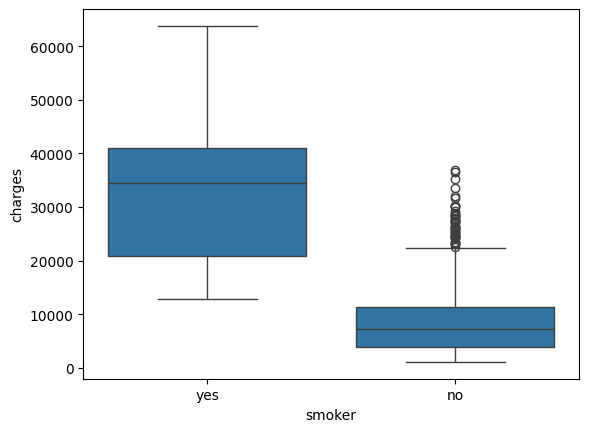

In [19]:
sns.boxplot(data=df,x="smoker",y="charges")

<Axes: xlabel='region', ylabel='charges'>

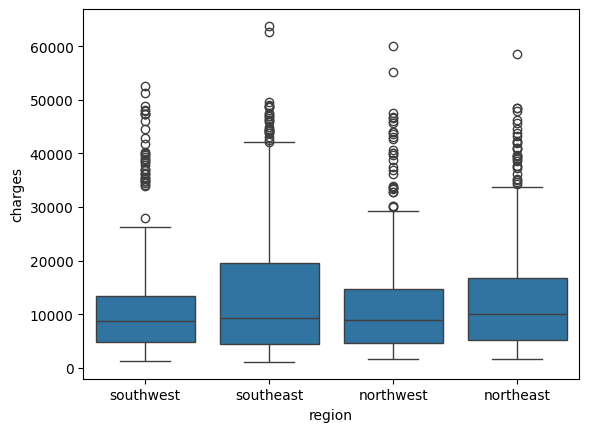

In [20]:
sns.boxplot(data=df,x="region",y="charges")

<Axes: xlabel='sex', ylabel='count'>

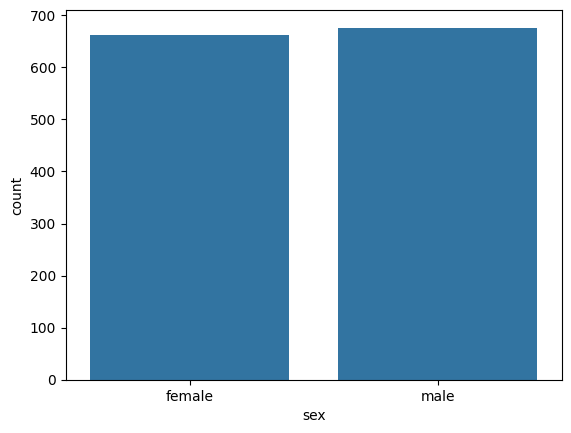

In [22]:
sns.countplot(data=df,x="sex")

In [24]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [28]:
df=df.drop_duplicates()

<Axes: >

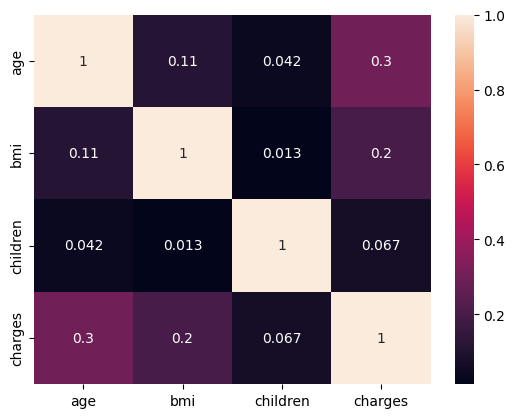

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [32]:
x=df[["age"]]
y=df[["charges"]]

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=25)

In [35]:
X_train.shape

(1069, 1)

In [36]:
X_test.shape

(268, 1)

In [38]:
y_train.shape

(1069, 1)

In [37]:
y_test.shape

(268, 1)

In [39]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [40]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [41]:
model.coef_

array([[242.56517294]])

In [42]:
model.intercept_

array([3769.43670064])

In [43]:
y_pred=model.predict(X_test)

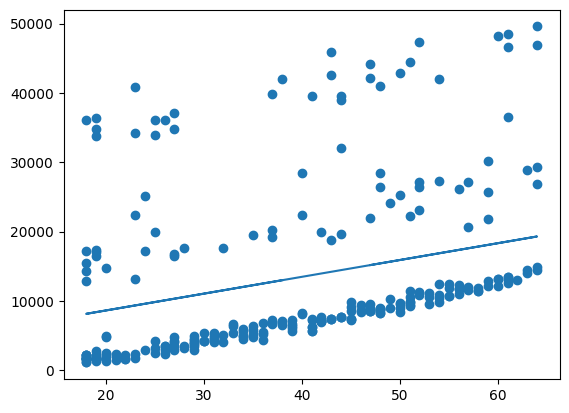

In [46]:
plt.plot(X_test,y_pred)
plt.scatter(X_test,y_test)

In [48]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [53]:
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

128861064.35074122
9116.657574899964
0.12593245991342916


In [67]:
x=df.drop(["charges"],axis=1)
x=pd.get_dummies(x)
y=df[["charges"]]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(model.coef_)
print(model.intercept_)

32368228.832193077
3924.636038021779
0.7497814388540703
[[   255.90356896    386.95479874    579.93610864    261.0019698
    -261.0019698  -11795.62196519  11795.62196519    676.0356847
     207.94627325   -681.32491881   -202.65703914]]
[-2266.41223876]


In [68]:
x

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,False,True,True,False,False,True,False,False
1334,18,31.920,0,True,False,True,False,True,False,False,False
1335,18,36.850,0,True,False,True,False,False,False,True,False
1336,21,25.800,0,True,False,True,False,False,False,False,True


In [80]:
# age1=20,bmi1=28,children1=2,sex1=male,smoker1=yes,region1=northeast
model.predict(np.array([[20,28,2,0,1,0,1,1,0,0,0]]))

C:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[27056.92140259]])

In [72]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

In [2]:
df=pd.read_csv("Fish.csv")
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [7]:
# x=df.drop(["Weight"],axis=1)
# x=pd.get_dummies(x)
# y=df[["Weight"]]
# r2=[]
# test=[0.05,0.1,0.15,0.2,0.25]
# index1=0
# for i in test:
#     x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
#     model=LinearRegression()
#     model.fit(x_train,y_train)
#     y_pred=model.predict(x_test)
#     index2=r2_score(y_test,y_pred)
#     r2=r2+[index2]
#     if index1<index2:
#         index1=index2
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# model=LinearRegression()
# model.fit(x_train,y_train)
# y_pred=model.predict(x_test)
# index2=r2_score(y_test,y_pred)
# y_ans=model.predict(np.array[[20,20,20,10,5]])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use only 5 numeric features
x = df[['Length1','Length2','Length3','Height','Width']]
y = df[['Weight']]

r2 = []
test = [0.05,0.1,0.15,0.2,0.25]

best_score = 0
best_test_size = 0

for i in test:
    
    x_train,x_test,y_train,y_test = train_test_split(
        x,y,test_size=i,random_state=42
    )
    
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    
    score = r2_score(y_test,y_pred)
    r2.append(score)
    
    if score > best_score:
        best_score = score
        best_test_size = i


# Train final model using best test size
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=best_test_size,random_state=42
)

model = LinearRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

final_r2 = r2_score(y_test,y_pred)
# prediction using 5 values
y_ans = model.predict(np.array([[20,20,20,10,5]]))

print("Best Test Size:",best_test_size)
print("Final R2 Score:",final_r2)
print("Predicted Weight:",y_ans)

Best Test Size: 0.15
Final R2 Score: 0.8980209372627835
Predicted Weight: [[420.99443233]]


C:\Users\yuvra\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


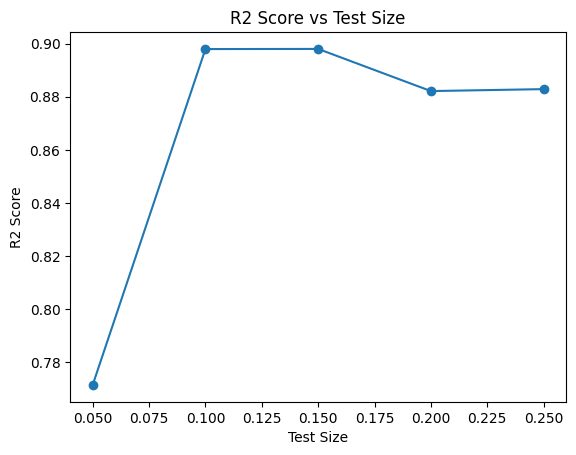

In [8]:
plt.plot(test,r2,marker='o')
plt.xlabel("Test Size")
plt.ylabel("R2 Score")
plt.title("R2 Score vs Test Size")
plt.show()

In [10]:
x_train.head(1)

,Length1,Length2,Length3,Height,Width
31,35.0,38.5,44.0,18.084,6.292
